# 01b · The zoo of forward processes

Notebook 01 built **VP** (shrink + add noise) and met **VE** (just add louder
noise). Both use Gaussian noise — but here's the thing:

> **Nothing in the mathematics requires noise at all.**

A forward process only has to satisfy three requirements:

1. **Destroy information progressively** — each step removes a little structure.
2. **End somewhere you can sample from** — you must be able to *draw* an
   $x_T$ to start generation from, without knowing any real data.
3. **Take small, invertible-in-distribution steps** — so a network can learn to
   undo one.

That's a surprisingly loose spec, and researchers have filled it with some very
strange things: blurring, masking, pixelation, electrostatics. This notebook
takes the tour, in 2D, where you can see everything.

Requirement **2** is the one that quietly kills naive ideas — watch for it in §2.

> ### 🧭 A guided tour
> This notebook is exploratory, not an exercise — every cell runs as-is. Read,
> run, and fiddle. The one cell meant for editing is marked at the end.


In [1]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from nanodiffusion.utils import set_seed, scatter_2d
from nanodiffusion.data import toy2d
from nanodiffusion.schedules import NoiseSchedule

set_seed(0)
T = 200
data = toy2d("swiss_roll", 8000)
schedule = NoiseSchedule.make("cosine", T)
ab = schedule.alpha_bars           # (T,) our familiar signal dial
print("data:", tuple(data.shape))

data: (8000, 2)


## 1. The Gaussian trio: VP, VE, and sub-VP

Song et al. (2021) framed diffusion as an SDE and identified **three** members,
not two. The third, **sub-VP**, is a small tweak to VP that gives strictly lower
variance — and the best likelihoods of the three.

In discrete form all three are one-liners. With $\bar\alpha_t$ as usual:

$$\textbf{VP:}\ \ x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon
\qquad
\textbf{sub-VP:}\ \ x_t=\sqrt{\bar\alpha_t}x_0+(1-\bar\alpha_t)\,\varepsilon
\qquad
\textbf{VE:}\ \ x_t=x_0+\sigma_t\,\varepsilon$$

Spot the difference: sub-VP uses $(1-\bar\alpha_t)$ where VP uses
$\sqrt{1-\bar\alpha_t}$. Since $(1-\bar\alpha)\le\sqrt{1-\bar\alpha}$, sub-VP
always injects *less* noise — yet still lands at $\mathcal N(0,I)$ when
$\bar\alpha_T\to0$, because both coefficients tend to 1 there.

The total variance tells the story:

$$\text{VP}:\ \bar\alpha+(1-\bar\alpha)=1 \qquad \text{sub-VP}:\ \bar\alpha+(1-\bar\alpha)^2 \qquad \text{VE}:\ 1+\sigma_t^2$$

sub-VP's variance **dips below 1** in the middle (minimum $0.75$ at
$\bar\alpha=\tfrac12$) — hence *sub*-variance-preserving.

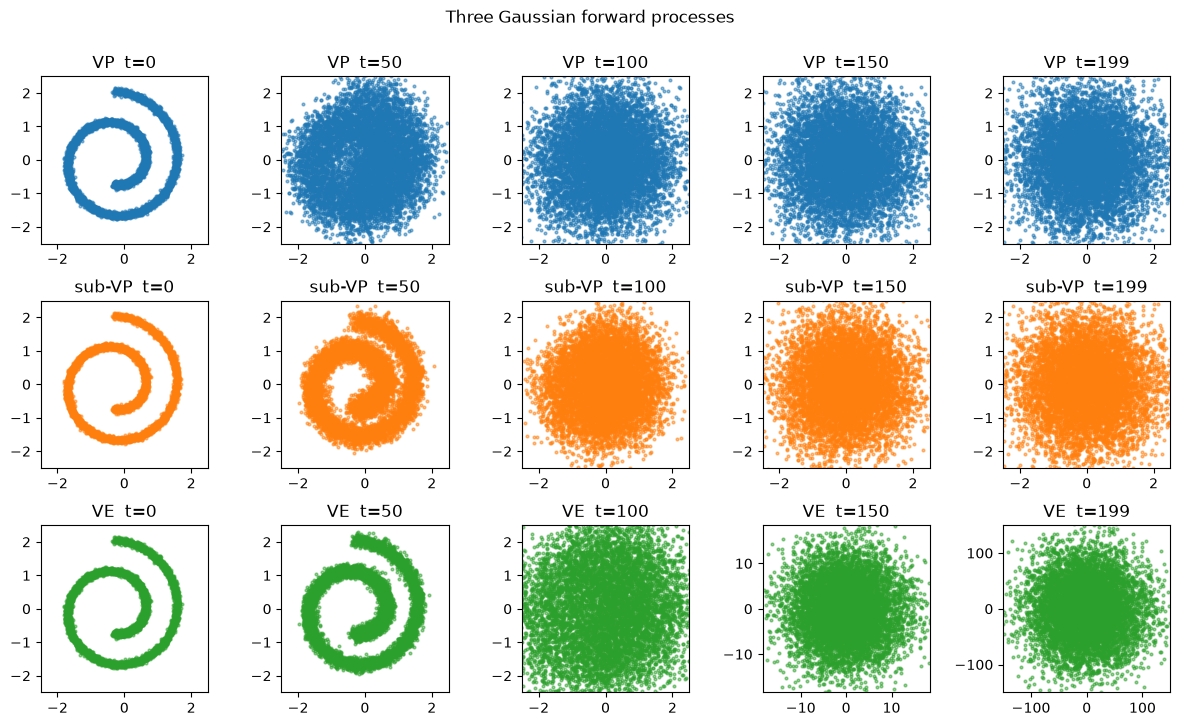

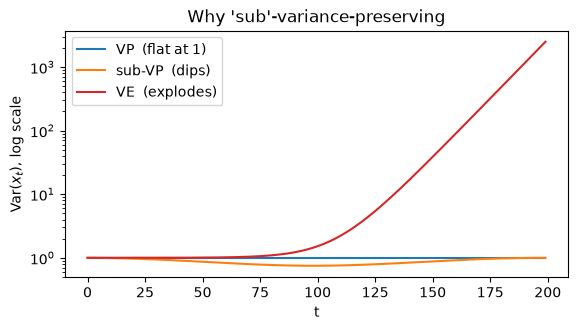

sub-VP minimum variance: 0.750 at abar=0.50  (theory: 0.75 at 0.50)


In [2]:
sigmas = torch.exp(torch.linspace(math.log(0.01), math.log(50.0), T))

def vp(x0, ti, eps):     return ab[ti].sqrt() * x0 + (1 - ab[ti]).sqrt() * eps
def subvp(x0, ti, eps):  return ab[ti].sqrt() * x0 + (1 - ab[ti]) * eps
def ve(x0, ti, eps):     return x0 + sigmas[ti] * eps

eps = torch.randn_like(data)
ts_show = [0, 50, 100, 150, 199]
fig, axes = plt.subplots(3, len(ts_show), figsize=(2.4 * len(ts_show), 7.2))
for row, (name, fn) in enumerate([("VP", vp), ("sub-VP", subvp), ("VE", ve)]):
    for col, ti in enumerate(ts_show):
        x_t = fn(data, ti, eps)
        lim = 2.5 if name != "VE" else max(2.5, 3 * sigmas[ti].item())
        scatter_2d(axes[row, col], x_t, f"{name}  t={ti}", lim=lim, color=f"C{row}")
plt.suptitle("Three Gaussian forward processes", y=1.0)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6.5, 3.2))
plt.plot(ab + (1 - ab), label="VP  (flat at 1)")
plt.plot(ab + (1 - ab) ** 2, label="sub-VP  (dips)")
plt.plot(1 + sigmas ** 2, label="VE  (explodes)", color="C3")
plt.yscale("log"); plt.xlabel("t"); plt.ylabel(r"Var($x_t$), log scale")
plt.legend(); plt.title("Why 'sub'-variance-preserving"); plt.show()
print(f"sub-VP minimum variance: {(ab + (1-ab)**2).min():.3f} "
      f"at abar={ab[(ab + (1-ab)**2).argmin()]:.2f}  (theory: 0.75 at 0.50)")

## 2. Cold diffusion — no noise whatsoever ❄️

**Cold Diffusion** (Bansal et al., 2022) asked the obvious-in-hindsight question:
does the corruption have to be *random*? They tried **blur, masking,
downsampling, pixelation — even "snowification"** — all fully deterministic, and
all of them work.

Our 2D version: **progressive quantization**. Snap every point to a grid, and
make the grid coarser over time:

$$x_t = \text{round}\!\left(\frac{x_0}{h_t}\right)\cdot h_t,\qquad h_t \text{ growing}$$

No randomness anywhere. Information dies because many distinct points collapse
onto the same lattice site.

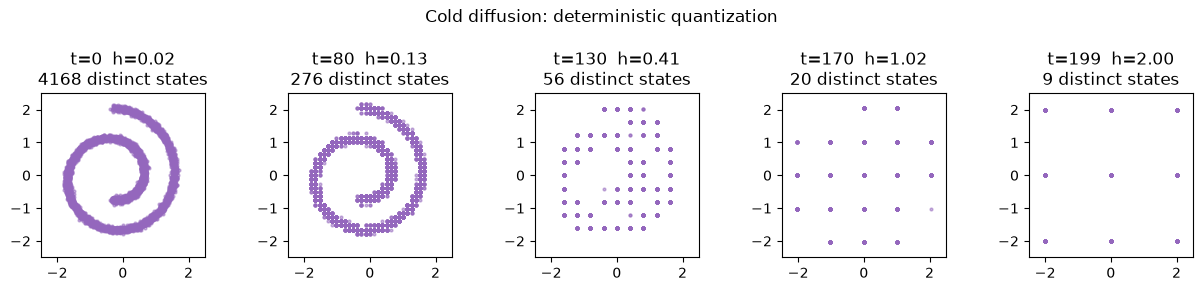

distinct states remaining (from 8000 points):
  t=  0  h= 0.02  ->   4168
  t= 80  h= 0.13  ->    276
  t=130  h= 0.41  ->     56
  t=170  h= 1.02  ->     20
  t=199  h= 2.00  ->      9


In [3]:
h = torch.exp(torch.linspace(math.log(0.02), math.log(2.0), T))   # cell size

def quantize(x0, ti):
    return torch.round(x0 / h[ti]) * h[ti]

ts_show = [0, 80, 130, 170, 199]
fig, axes = plt.subplots(1, len(ts_show), figsize=(2.5 * len(ts_show), 2.6))
for ax, ti in zip(axes, ts_show):
    x_t = quantize(data, ti)
    n_states = torch.unique(x_t, dim=0).shape[0]
    scatter_2d(ax, x_t, f"t={ti}  h={h[ti]:.2f}\n{n_states} distinct states", color="C4")
plt.suptitle("Cold diffusion: deterministic quantization", y=1.04)
plt.tight_layout(); plt.show()

print("distinct states remaining (from 8000 points):")
for ti in [0, 80, 130, 170, 199]:
    print(f"  t={ti:3d}  h={h[ti]:5.2f}  ->  {torch.unique(quantize(data, ti), dim=0).shape[0]:5d}")

### The catch — requirement 2 bites

Look at the last column: the swiss roll has collapsed to a handful of lattice
sites. That's *fine* — it's a **categorical distribution** we can sample from, so
generation could start by drawing a lattice site and walking backwards.

But push the grid coarser and every point maps to a **single** site. The end
state becomes a *delta* — one deterministic value. Now sampling is impossible:
every generation run would start from the identical $x_T$ and, with a
deterministic reverse map, produce the identical output. **No diversity.**

This is the real constraint on exotic forward processes: they must leave a
*distribution* at $t=T$, not a point. Cold Diffusion handles it partly by
choosing degradations that don't fully collapse, and partly with a corrected
sampling algorithm — naively inverting a deterministic map accumulates error
badly.

> **Gaussian noise isn't magic, but it is convenient:** it hands you a
> known, easy-to-sample end distribution for free.

## 3. Blurring — the heat equation as a forward process 🔥

**Inverse Heat Dissipation** (Rissanen et al., 2022) uses actual physics: run the
**heat equation** on the image and structure melts away. In Fourier space the
solution is beautifully simple — each frequency decays at a rate set by its
wavenumber:

$$\hat u(k,\tau)=\hat u(k,0)\,e^{-\|k\|^2\tau}$$

High frequencies (fine detail) die **fast**; low frequencies (coarse layout)
survive. So the reverse process generates **coarse-to-fine** — the opposite
character to VP, which degrades all frequencies fairly evenly.

Since blurring acts on a density rather than individual points, we rasterize the
swiss roll to an image first.

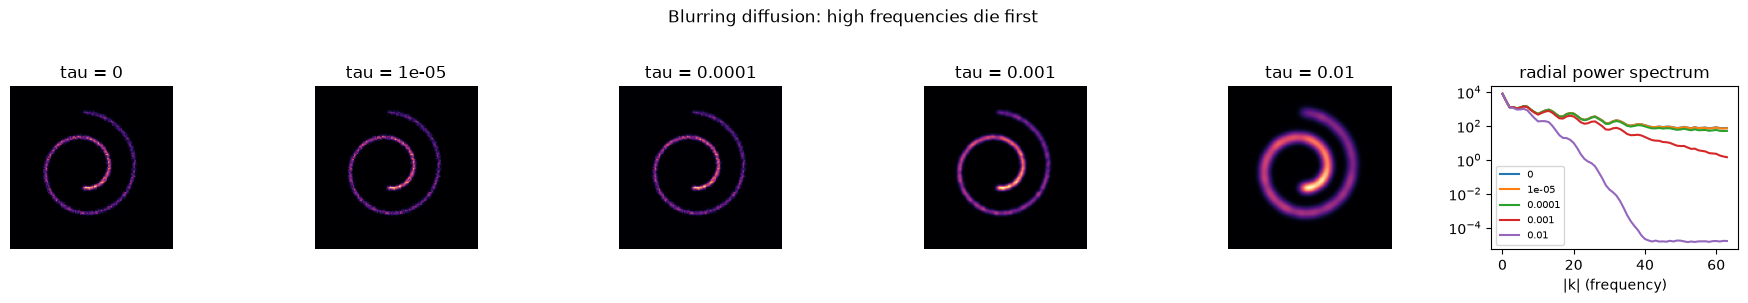

In [4]:
def density(points, bins=128, rng=3.0):
    H, _, _ = np.histogram2d(points[:, 0].numpy(), points[:, 1].numpy(),
                             bins=bins, range=[[-rng, rng], [-rng, rng]])
    return torch.tensor(H.T, dtype=torch.float32)

def heat(d, tau):
    '''Exact heat-equation solution: damp each Fourier mode by exp(-|k|^2 tau).'''
    N = d.shape[-1]
    k = torch.fft.fftfreq(N) * N
    KX, KY = torch.meshgrid(k, k, indexing="ij")
    return torch.fft.ifft2(torch.fft.fft2(d) * torch.exp(-(KX**2 + KY**2) * tau)).real

def radial_spectrum(d):
    F = torch.fft.fftshift(torch.abs(torch.fft.fft2(d)))
    N = d.shape[0]; c = N // 2
    yy, xx = torch.meshgrid(torch.arange(N) - c, torch.arange(N) - c, indexing="ij")
    r = torch.sqrt((xx**2 + yy**2).float()).round().long()
    return torch.stack([F[r == i].mean() for i in range(c)])

d0 = density(data)
taus = [0.0, 1e-5, 1e-4, 1e-3, 1e-2]

fig, axes = plt.subplots(1, len(taus) + 1, figsize=(3.0 * (len(taus) + 1), 2.9))
for ax, tau in zip(axes, taus):
    ax.imshow(heat(d0, tau), origin="lower", cmap="magma")
    ax.set_title(f"tau = {tau:g}"); ax.axis("off")
axes[-1].set_title("radial power spectrum")
for tau in taus:
    axes[-1].plot(radial_spectrum(heat(d0, tau)), label=f"{tau:g}")
axes[-1].set_yscale("log"); axes[-1].set_xlabel("|k| (frequency)"); axes[-1].legend(fontsize=7)
plt.suptitle("Blurring diffusion: high frequencies die first", y=1.03)
plt.tight_layout(); plt.show()

The spectrum panel is the whole story: as $\tau$ grows the curve is pinned at low
$|k|$ but collapses on the right. **Detail is destroyed before layout.**

There's a lovely twist. **Blurring Diffusion Models** (Hoogeboom & Salimans,
2023) proved that blurring is *equivalent* to ordinary diffusion with a
**non-isotropic noise schedule in frequency space** — a different $\bar\alpha_t$
per frequency. So this exotic-looking process folds right back into the framework
from notebook 01. The zoo is more connected than it first appears.

## 4. Masking — and why BERT is a diffusion model 🎭

For **discrete** data (text, molecules) Gaussian noise makes no sense — there's
no "halfway between token 4 and token 9". **D3PM** (Austin et al., 2021) instead
defines the forward process as a Markov chain over states. The most useful
variant is **absorbing-state**: at each step, replace a token with `[MASK]` with
some probability. Once masked, always masked.

Run that to completion and every token is `[MASK]`. The reverse process fills
them back in — which is to say, **masked language modelling is the reverse of an
absorbing diffusion process.** This equivalence is the foundation of today's
diffusion LLMs.

In 2D we mask *coordinates*, sending them to 0. Watch the swiss roll collapse
onto the axes and then to the origin.

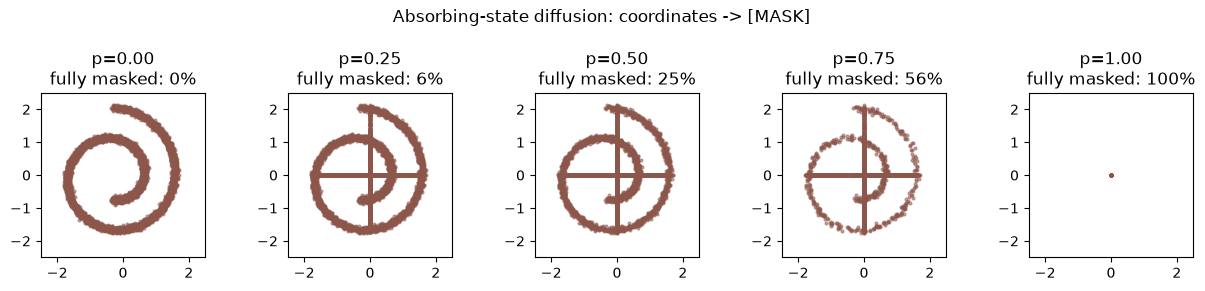

In [5]:
def mask_forward(x0, p, seed=0):
    g = torch.Generator().manual_seed(seed)
    m = torch.rand(x0.shape, generator=g) < p          # True = masked
    return torch.where(m, torch.zeros_like(x0), x0), m

ps = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(ps), figsize=(2.5 * len(ps), 2.6))
for ax, p in zip(axes, ps):
    x_t, m = mask_forward(data, p)
    frac_both = (m.all(dim=1)).float().mean()
    scatter_2d(ax, x_t, f"p={p:.2f}\nfully masked: {frac_both:.0%}", color="C5")
plt.suptitle("Absorbing-state diffusion: coordinates -> [MASK]", y=1.04)
plt.tight_layout(); plt.show()

Note what the middle panels show: points with $x$ masked land on the vertical
axis, points with $y$ masked land on the horizontal one, and points with both
masked sit at the origin — a cross that thickens into a single point.

The end state here **is** a delta (everything masked) — exactly what §2 warned
about. So why does it work? Because the reverse model is **stochastic**: it
predicts a *distribution* over what each masked value should be and samples from
it. The diversity comes from the reverse process, not the forward one. That's the
escape hatch cold diffusion lacks with a deterministic decoder.

## 5. The endpoint doesn't have to be noise 🌉

Every process so far ends at something structureless. But **stochastic
interpolants** (Albergo & Vanden-Eijnden, 2023) point out you can connect **any
two distributions**:

$$x_t=\alpha(t)\,x_0+\beta(t)\,x_1+\gamma(t)\,z$$

Pick $x_1\sim\mathcal N(0,I)$ and you recover diffusion. Pick $x_1$ to be
*another dataset* and you get a **bridge** between them — the idea behind
Schrödinger-bridge methods and I²SB, which are far more efficient for
image-to-image tasks than routing through pure noise.

Let's morph the swiss roll into two moons. **No noise appears anywhere.**

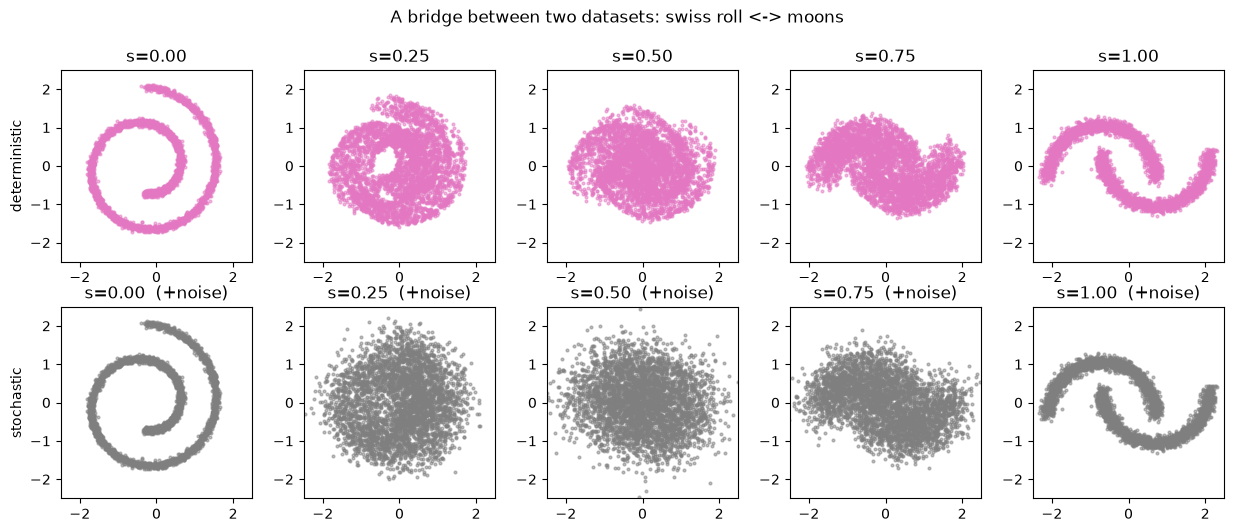

In [6]:
set_seed(1)
A = toy2d("swiss_roll", 4000)
B = toy2d("moons", 4000)                 # independent (random) coupling

ss = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(2, len(ss), figsize=(2.5 * len(ss), 5.2))
for j, s in enumerate(ss):
    scatter_2d(axes[0, j], (1 - s) * A + s * B, f"s={s:.2f}", color="C6")
    gamma = 0.35 * math.sin(math.pi * s)          # optional noise bump in the middle
    x = (1 - s) * A + s * B + gamma * torch.randn_like(A)
    scatter_2d(axes[1, j], x, f"s={s:.2f}  (+noise)", color="C7")
axes[0, 0].set_ylabel("deterministic"); axes[1, 0].set_ylabel("stochastic")
plt.suptitle("A bridge between two datasets: swiss roll <-> moons", y=1.0)
plt.tight_layout(); plt.show()

The top row is a pure **interpolant** — a straight line in data space, which is
exactly the path **flow matching / rectified flow** learns (notebook 08). The
bottom row adds a $\gamma(t)$ noise bump that vanishes at both ends, which is what
makes it *stochastic*.

One caveat worth knowing: we paired points **randomly**. That's the "independent
coupling", and it makes paths cross each other, which is harder to learn. Choosing
an **optimal-transport** coupling instead gives straighter, non-crossing paths —
the trick behind OT-CFM and rectified flow's "reflow" step, and a big part of why
those models sample in so few steps.

## 6. Beyond Gaussian: does the noise have to be Gaussian?

Sections 1–5 changed the *process*. Here we change the **noise itself**: keep
"add noise, learn to remove it", but draw $\varepsilon$ from something other than a
bell curve.

Why is Gaussian the universal default? It comes back to the **nice property** from
notebook 01 — jumping from $x_0$ to $x_t$ in one shot needs the noise family to be
**stable under addition**: the sum of independent draws must stay the *same shape*.
A theorem (the generalized central limit theorem) says the only families with that
property are the **$\alpha$-stable** distributions, indexed by a tail parameter
$\alpha \in (0, 2]$:

| $\alpha$ | distribution | tails | variance |
|---|---|---|---|
| 2 | **Gaussian** | light | finite |
| 1 | Cauchy | heavy | infinite |
| 1/2 | Lévy | very heavy | infinite |

So **Gaussian is the *unique* $\alpha$-stable distribution with finite variance** —
the lightest-tailed, best-behaved member. That's why it's the default. But its
heavy-tailed cousins are stable too, so they *also* get a nice property — which is
exactly what makes **Lévy / $\alpha$-stable diffusion** work cleanly.

First, let's just *look* at different noises.

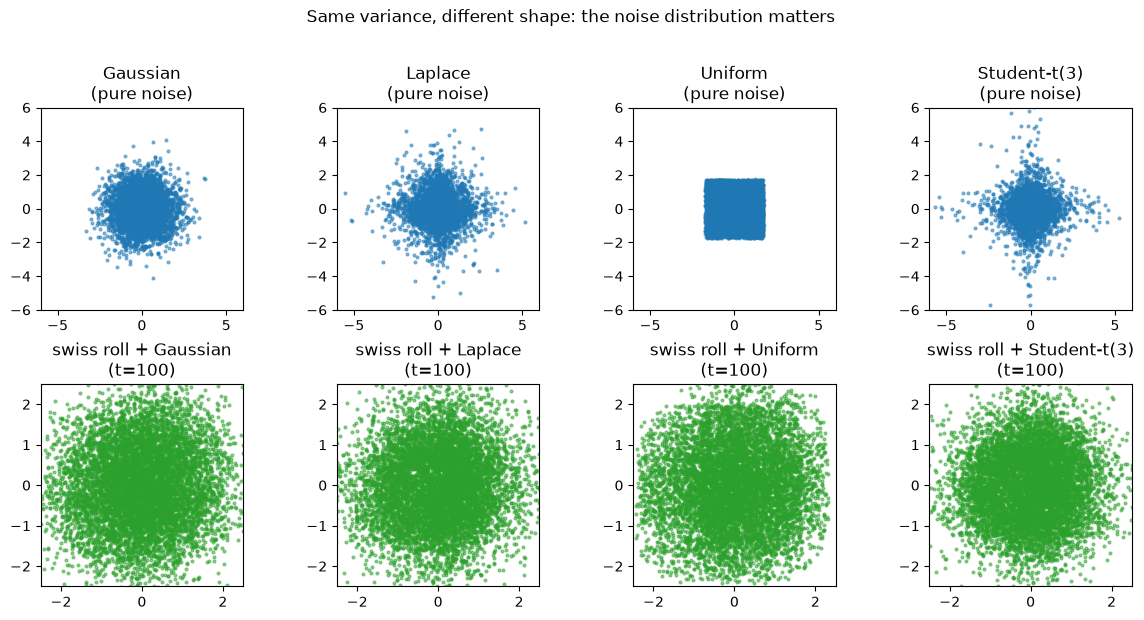

In [7]:
import torch.distributions as D
from math import sqrt

# Each sampler returns ~unit-variance samples, so the SHAPE is what differs (not scale).
NOISES = {
    "Gaussian":   lambda n: D.Normal(0., 1.).sample((n, 2)),
    "Laplace":    lambda n: D.Laplace(0., 1/sqrt(2)).sample((n, 2)),      # var = 2b^2 = 1
    "Uniform":    lambda n: D.Uniform(-sqrt(3), sqrt(3)).sample((n, 2)),  # var = a^2/3 = 1
    "Student-t(3)": lambda n: D.StudentT(3.).sample((n, 2)) / sqrt(3.),   # var = 3/(3-2)=3
}

set_seed(0)
fig, axes = plt.subplots(2, len(NOISES), figsize=(3 * len(NOISES), 6))
for j, (name, sampler) in enumerate(NOISES.items()):
    eps = sampler(4000)
    scatter_2d(axes[0, j], eps, f"{name}\n(pure noise)", lim=6)
    # add it to the swiss roll at a moderate level (t=100, ~half signal / half noise)
    x_t = ab[100].sqrt() * data + (1 - ab[100]).sqrt() * sampler(data.shape[0])
    scatter_2d(axes[1, j], x_t, f"swiss roll + {name}\n(t=100)", color="C2")
plt.suptitle("Same variance, different shape: the noise distribution matters", y=1.02)
plt.tight_layout(); plt.show()

Look at the top row — all four have the **same variance**, yet very different
shapes:

- **Gaussian** — round, isotropic. No preferred direction.
- **Laplace** — a diamond/star: mass concentrates along the axes and the tails are
  heavier than Gaussian (more medium-range points).
- **Uniform** — a hard-edged box. Bounded: *no* outliers, ever.
- **Student-t** — a tight round core **plus points flung far out** (note the ones
  near the edges at ±6). That's a heavy tail.

The bottom row shows why it matters for a forward process: heavy-tailed noise
(Student-t) sprays occasional points far from the manifold, while uniform noise can
never move a point beyond a fixed radius. The corruption has a *character*, not
just a magnitude.

### Which of these keep the nice property?

Only the **stable** ones. Here's the empirical test: take a distribution, sum $k$
independent draws, rescale to fix the variance, and see if the shape is unchanged.
Gaussian should be invariant; Laplace should *not* be.

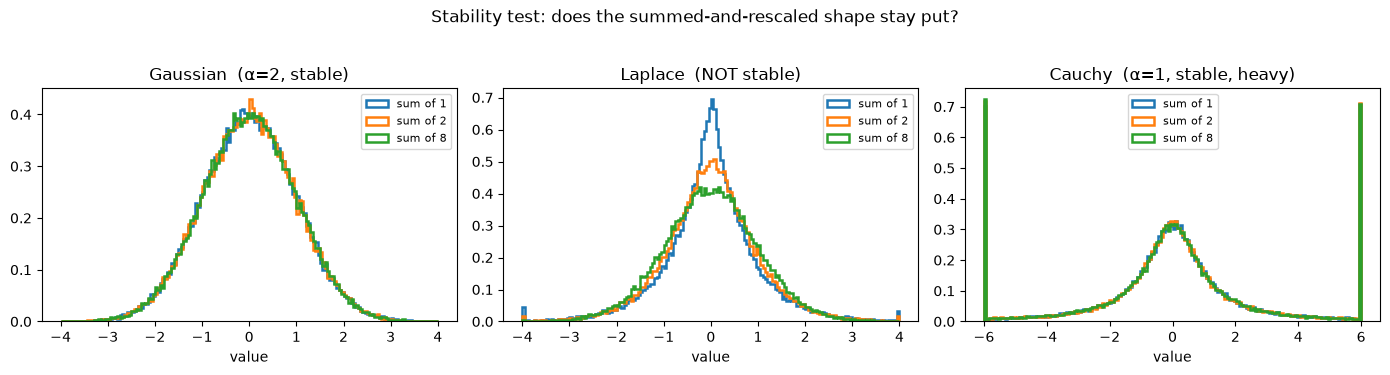

In [8]:
def normalized_sum(sampler, k, N, scale_pow=0.5):
    # sum of k iid draws, rescaled by k^(-scale_pow) to hold the spread fixed
    s = sum(sampler(N) for _ in range(k))
    return s / (k ** scale_pow)

set_seed(0)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
panels = [
    ("Gaussian  (α=2, stable)",      lambda n: D.Normal(0., 1.).sample((n,)),         0.5, (-4, 4)),
    ("Laplace  (NOT stable)",        lambda n: D.Laplace(0., 1/sqrt(2)).sample((n,)), 0.5, (-4, 4)),
    ("Cauchy  (α=1, stable, heavy)", lambda n: D.Cauchy(0., 1.).sample((n,)),         1.0, (-6, 6)),
]
for ax, (title, sampler, p, rng) in zip(axes, panels):
    for k in [1, 2, 8]:
        v = normalized_sum(sampler, k, 60000, scale_pow=p).clamp(*rng)
        ax.hist(v.numpy(), bins=160, range=rng, density=True, histtype="step",
                lw=1.8, label=f"sum of {k}")
    ax.set_title(title); ax.set_xlabel("value"); ax.legend(fontsize=8)
plt.suptitle("Stability test: does the summed-and-rescaled shape stay put?", y=1.03)
plt.tight_layout(); plt.show()

Read the three panels:

- **Gaussian** — the three curves lie exactly on top of each other. Summing
  Gaussians gives a Gaussian; it's **stable**. ✔ nice property.
- **Laplace** — the sharp $k=1$ peak *flattens and rounds toward a bell* as you sum
  more. A sum of Laplaces is **not** a Laplace (it drifts to Gaussian, by the CLT).
  ✘ no clean closed-form marginal.
- **Cauchy** — heavy tails, yet the curves **also coincide** (with $1/k$ scaling,
  not $1/\sqrt{k}$). It's stable despite being nothing like a Gaussian — proof that
  "stable" is a *bigger* club than "Gaussian".

So the honest picture: **α-stable ⟹ nice property**. Gaussian is simply the comfy,
finite-variance corner of that family.

### The catch, and real models

Two things change when you leave Gaussian:

1. **The loss is no longer plain MSE.** MSE is the maximum-likelihood fit *for
   Gaussian noise specifically* (predicting $\varepsilon$ = predicting the mean).
   Laplace noise wants an **L1** loss; heavy-tailed α-stable noise needs a
   **fractional score**; Gamma needs its own target. Swap the noise → swap the
   objective.
2. **Heavy tails buy exploration.** α-stable noise can take big jumps ("Lévy
   flights"), helping the model **hop between modes** and cover rare data a Gaussian
   smooths over — at the cost of infinite variance and a trickier score.

Real models that do exactly this:

| Model | Noise | Idea |
|---|---|---|
| **DDGM** (2021) | Gamma | positive, skewed noise; small gains on images & speech |
| **Lévy / α-stable diffusion, DLPM** (2023–24) | α-stable | heavy tails, better rare-mode coverage |
| **Heavy-tailed diffusion** (2024) | Student-t | match heavy-tailed data, cover the tails |

### 🔧 Try your own noise

Edit `my_noise` and re-run. Try `D.Laplace`, a bimodal mix, or crank the Student-t
degrees of freedom down (heavier tails).

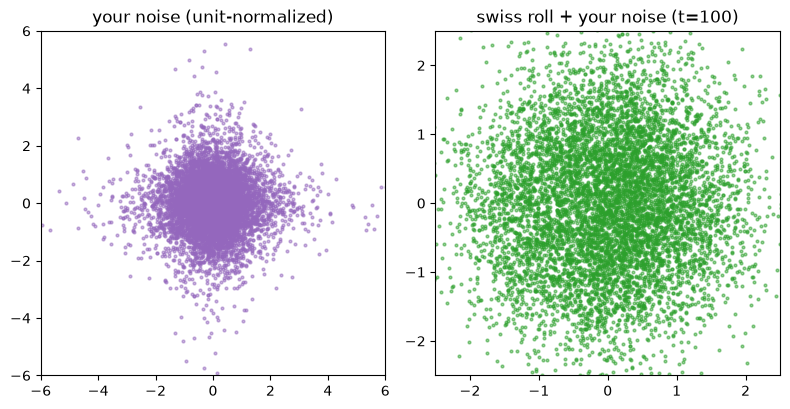

noise std = 1.000   |   farthest point = 7.9  (big = heavy tails)


In [9]:
def my_noise(n):
    '''Return n×2 noise samples from any distribution. <- EDIT ME'''
    return D.StudentT(5.).sample((n, 2))          # heavy-tailed; try df=2 or D.Laplace(0.,1.)

set_seed(0)
raw = my_noise(data.shape[0])
raw = raw / raw.std()                              # unit-normalize for a fair scale
x_t = ab[100].sqrt() * data + (1 - ab[100]).sqrt() * raw

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 4))
scatter_2d(a1, raw, "your noise (unit-normalized)", lim=6, color="C4")
scatter_2d(a2, x_t, "swiss roll + your noise (t=100)", color="C2")
plt.tight_layout(); plt.show()
print(f"noise std = {raw.std():.3f}   |   farthest point = {raw.abs().max():.1f}  "
      f"(big = heavy tails)")

## 7. The rest of the zoo

| Approach | The idea | Reference |
|---|---|---|
| **sub-VP** | lower-variance sibling of VP; best likelihoods of the trio | Song et al. 2021 |
| **Critically-damped Langevin (CLD)** | add a **velocity** variable and noise only *that*; data is never noised directly | Dockhorn et al. 2022 |
| **Cold diffusion** | any deterministic degradation: blur, mask, pixelate, snow | Bansal et al. 2022 |
| **Inverse heat dissipation** | the heat equation; coarse-to-fine generation | Rissanen et al. 2022 |
| **Blurring diffusion** | proves blurring ≡ diffusion with a per-frequency schedule | Hoogeboom & Salimans 2023 |
| **D3PM / absorbing** | Markov chains on discrete states; masking as diffusion | Austin et al. 2021 |
| **Stochastic interpolants** | connect *any* two distributions; unifies flows and diffusions | Albergo & Vanden-Eijnden 2023 |
| **Schrödinger bridge / I²SB** | optimal-transport path between two datasets | De Bortoli et al. 2021; Liu et al. 2023 |
| **Flow matching / rectified flow** | straight-line paths, no SDE | Lipman et al. 2022; Liu et al. 2022 |
| **PFGM++** | **electrostatics** — data as charges, follow field lines; diffusion is its $D\to\infty$ limit | Xu et al. 2022, 2023 |
| **Bayesian Flow Networks** | diffuse the *parameters of a distribution*, not the data | Graves et al. 2023 |
| **Riemannian / SE(3) diffusion** | diffusion on manifolds — spheres, rotations, protein backbones | De Bortoli et al. 2022 |

The pattern: once you see the forward process as "any information-destroying path
to a samplable endpoint", the design space opens enormously — and most of these
turn out to be **special cases of one another** when viewed through the SDE or
interpolant lens. That unification is notebook 07's job.

## 8. 🔧 Your turn — invent a forward process

Edit `my_degradation` below. It takes clean data and a progress value
$s\in[0,1]$ (0 = untouched, 1 = fully destroyed) and returns the corrupted data.
The report checks your process against the three requirements.

Ideas: rotate while shrinking · project onto a random line · add increasing
Laplace (heavy-tailed) noise instead of Gaussian · sort the coordinates ·
progressively swap points between two datasets.

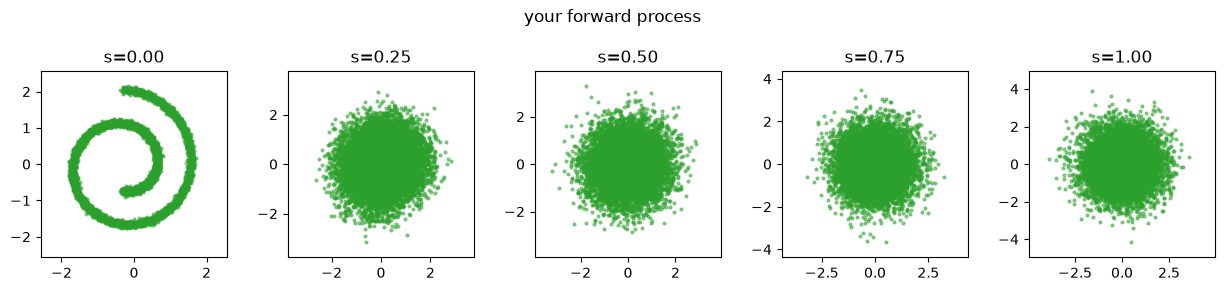

correlation with x0 at s=1 : [-0.021, 0.017]   (want ~0)
spread (std) at s=1        : [1.008, 1.014]   (want > 0, else nothing to sample)

[1] information destroyed   : OK
[2] endpoint is samplable   : OK


In [10]:
def my_degradation(x0, s):
    '''s in [0,1]: 0 = clean, 1 = destroyed.   <- EDIT ME'''
    # example: spiral inward while adding noise (a rotating VP)
    theta = 4 * math.pi * s
    R = torch.tensor([[math.cos(theta), -math.sin(theta)],
                      [math.sin(theta),  math.cos(theta)]])
    return (1 - s) * (x0 @ R.T) + math.sqrt(max(s, 0.0)) * torch.randn_like(x0)


def report(fn, n_show=5):
    ss = torch.linspace(0, 1, n_show)
    fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 2.6))
    for ax, s in zip(axes, ss):
        x = fn(data, float(s))
        lim = max(2.5, 1.2 * x.abs().max().item())
        scatter_2d(ax, x, f"s={s:.2f}", lim=lim, color="C2")
    plt.suptitle("your forward process", y=1.04); plt.tight_layout(); plt.show()

    x_end = fn(data, 1.0)
    # req 1: does the end still remember x0?  (correlation per coordinate)
    corr = [float(np.corrcoef(data[:, i].numpy(), x_end[:, i].numpy())[0, 1])
            for i in range(2)]
    # req 2: is the endpoint a distribution, or a single point?
    spread = x_end.std(dim=0)
    print(f"correlation with x0 at s=1 : {[round(c, 3) for c in corr]}   (want ~0)")
    print(f"spread (std) at s=1        : {[round(float(v), 3) for v in spread]}"
          f"   (want > 0, else nothing to sample)")
    ok1 = max(abs(c) for c in corr) < 0.15
    ok2 = float(spread.min()) > 0.05
    print(f"\n[1] information destroyed   : {'OK' if ok1 else 'still correlated with the data'}")
    print(f"[2] endpoint is samplable   : {'OK' if ok2 else 'collapsed to a point -- cannot generate'}")

report(my_degradation)

## Recap

A forward process needs only three things: **destroy information**, **end
somewhere samplable**, and **take learnable steps**. Gaussian noise is one
convenient way to get all three — not the only way.

- **sub-VP** completes the Gaussian trio; its variance dips below 1.
- **Cold diffusion** drops randomness entirely — but then the endpoint risks
  collapsing to a point, and there is nothing left to sample.
- **Blurring** destroys frequencies in order, giving coarse-to-fine generation —
  and is secretly a per-frequency noise schedule.
- **Masking** is the discrete case, where the endpoint *is* a single state and
  diversity comes from a **stochastic reverse model** instead.
- **Interpolants and bridges** show the endpoint needn't be noise at all — you
  can travel between two datasets.
- **Non-Gaussian noise** keeps the noising structure but swaps the distribution;
  only **α-stable** families keep the nice property, and Gaussian is just the
  finite-variance one — heavy-tailed noise (Lévy, Student-t) trades that for
  better rare-mode coverage and a non-MSE loss.

Back to the main line: **notebook 02** trains a network to reverse the VP process
you built in 01.